# SR3 RV Lab — Framework 2: same-strike calendar digitals (the coupling basis)

**RV class: B — cross-contract coupling.**

For two expiries and one common *rate* strike `K`, price the listed vertical
on each contract and normalise it to `P(rate >= K)`. The **digital calendar**
is `cal(K) = P_back(>=K) - P_front(>=K)`: the listed price of "the rate crosses
K between the front expiry and the back expiry".

### What is pinned, and what is free

For a non-negative rate, `E[f] = ∫_0^∞ P(f >= K) dK`, so

```
∫ [P_back(>=K) - P_front(>=K)] dK  =  E[f_back] - E[f_front]  =  the futures calendar spread
```

The **level** of the calendar-digital profile is therefore pinned by the linear
market — exactly the "no mean-level RV" rule. What is *not* pinned is **where
across strikes that spread sits**. That shape is the coupling content, and it
is what this notebook trades. The first analysis cell verifies the identity
numerically on real data rather than asserting it.

The tradeable object at a single strike is a 4-leg package (one vertical per
contract), scaled to one unit of probability: a 6.25bp vertical trades 16 lots
a side, a 25bp vertical 4 lots — always whole CME lots — so the package marks
at `100 x cal` bp.

In [1]:
CONFIG = dict(
    offsets=(-0.25, 0.0, 0.25),   # rate offsets from the front contract's forward
    strike_tol=0.10,              # max |target - bracket midpoint|, percent
    min_oi=100,
    pair_gaps=(1, 2),
    contracts_per_leg=100,
    cost_bp=2.5,                  # 4 option legs -> taker cost is generous here
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
)
CONFIG

{'offsets': (-0.25, 0.0, 0.25),
 'strike_tol': 0.1,
 'min_oi': 100,
 'pair_gaps': (1, 2),
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import (
    LabConfig, config_from_row, cost_block, exit_comparison, grid_block,
    header_block, league_row, load_lab, marks_x_lag_panel, median_row,
    stability_block, three_panel_equity,
)
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, contract_pairs, digital_calendar_panel,
    digital_legs, grid_search, hedge_each_contract, mark_structure,
    package_contracts, run_backtest, vertical_digital,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


## Step 1 — verify the level constraint on real data

Integrate the listed digital profile across the whole quoted strike ladder and
compare with the futures calendar spread. Agreement is the proof that only the
*shape* of this profile can carry relative value.

In [3]:
PAIRS = contract_pairs(sorted(contracts["symbol"].unique()), gaps=(1,))
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
fwd_px = contracts.set_index(["as_of", "symbol"])["forward_price"]
by_day = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}

check = []
for front, back in PAIRS:
    dates = sorted({t for (t, s) in by_day if s == front}
                   & {t for (t, s) in by_day if s == back})
    for ts in dates[::25]:                # sampling keeps this diagnostic cheap
        gf, gb = by_day[(ts, front)], by_day[(ts, back)]
        ladder = np.sort(np.unique(np.concatenate([
            gf["strike_rate"].to_numpy(), gb["strike_rate"].to_numpy()])))
        ladder = ladder[(ladder > 0) & (ladder < 12)]
        if ladder.size < 8:
            continue
        pf, pb, ks = [], [], []
        for k in ladder:
            a = vertical_digital(gf, float(k), tol=0.20,
                                 forward_price=float(fwd_px.get((ts, front), np.nan)))
            b = vertical_digital(gb, float(k), tol=0.20,
                                 forward_price=float(fwd_px.get((ts, back), np.nan)))
            if a is None or b is None:
                continue
            pf.append(a["prob"]); pb.append(b["prob"]); ks.append(float(k))
        if len(ks) < 8:
            continue
        integral = np.trapezoid(np.array(pb) - np.array(pf), np.array(ks)) * 100.0
        spread = (float(fwd.get((ts, back))) - float(fwd.get((ts, front)))) * 100.0
        check.append({"as_of": ts, "pair": f"{front}-{back}",
                      "integral_bp": integral, "futures_spread_bp": spread,
                      "gap_bp": integral - spread, "n_strikes": len(ks),
                      "strike_span": ks[-1] - ks[0]})
check = pd.DataFrame(check)
print(f"n checks: {len(check)}")
if not check.empty:
    print(check[["integral_bp", "futures_spread_bp", "gap_bp", "strike_span"]]
          .describe().round(2).to_string())
    print(f"\ncorrelation(integral, futures spread) = "
          f"{check['integral_bp'].corr(check['futures_spread_bp']):.4f}")
    print("The residual gap is the mass outside the quoted strike ladder "
          "(truncation), not tradeable slack.")
    from sfr_rv_lab_common import DATA_DIR as _DD
    check.to_csv(_DD / "level_constraint_check.csv", index=False)

n checks: 147
       integral_bp  futures_spread_bp  gap_bp  strike_span
count       147.00             147.00  147.00       147.00
mean         -7.66              -7.74    0.09         5.24
std          10.35              10.83    1.11         1.94
min         -37.50             -38.00   -2.13         2.94
25%         -14.08             -14.75   -0.49         3.75
50%          -5.23              -5.00    0.00         4.50
75%           0.13               0.00    0.57         5.69
max          15.49              15.50    4.27         9.50

correlation(integral, futures spread) = 0.9955
The residual gap is the mass outside the quoted strike ladder (truncation), not tradeable slack.


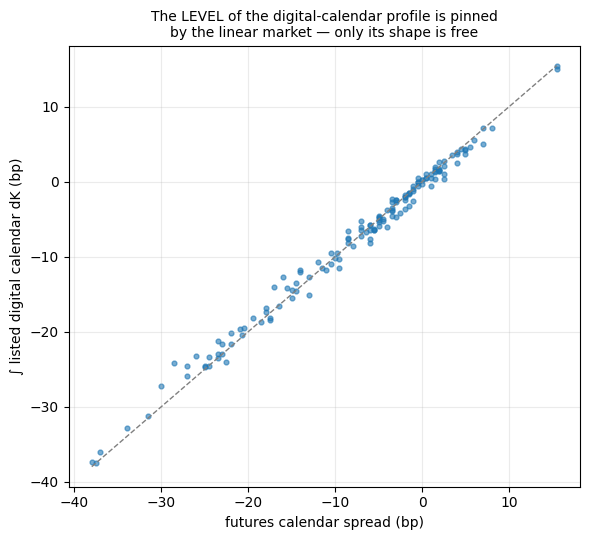

In [4]:
if not check.empty:
    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(check["futures_spread_bp"], check["integral_bp"], s=12, alpha=0.6)
    lim = [min(check["futures_spread_bp"].min(), check["integral_bp"].min()),
           max(check["futures_spread_bp"].max(), check["integral_bp"].max())]
    ax.plot(lim, lim, color="grey", lw=1, ls="--")
    ax.set_xlabel("futures calendar spread (bp)")
    ax.set_ylabel("∫ listed digital calendar dK (bp)")
    ax.set_title("The LEVEL of the digital-calendar profile is pinned\n"
                 "by the linear market — only its shape is free", fontsize=10)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## Step 2 — the signal panel

In [5]:
dc = digital_calendar_panel(
    quotes, contracts, offsets=CONFIG["offsets"],
    pairs=contract_pairs(sorted(contracts["symbol"].unique()),
                         gaps=CONFIG["pair_gaps"]),
    tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
print(f"rows: {len(dc)}   pairs: {dc['key'].nunique() if len(dc) else 0}")
if not dc.empty:
    print(dc.groupby("key")[["cal_atm", "fly"]].describe().round(3).to_string())

rows: 5929   pairs: 25
              cal_atm                                                fly                                                 
                count   mean    std   min   25%   50%   75%   max  count   mean    std    min    25%    50%    75%    max
key                                                                                                                      
SFRH25-SFRM25   170.0 -0.164  0.076 -0.48 -0.18 -0.16 -0.12  0.08  170.0  0.105  0.150 -0.320  0.000  0.080  0.160  0.680
SFRH25-SFRU25   172.0 -0.229  0.094 -0.60 -0.24 -0.22 -0.18  0.16  172.0  0.133  0.166 -0.480  0.020  0.100  0.200  0.680
SFRH26-SFRM26   390.0 -0.139  0.121 -0.58 -0.20 -0.10 -0.04  0.02  390.0  0.122  0.184 -0.120  0.000  0.060  0.160  1.080
SFRH26-SFRU26   342.0 -0.207  0.151 -0.60 -0.32 -0.20 -0.08  0.06  342.0  0.131  0.190 -0.120  0.000  0.060  0.188  1.000
SFRH27-SFRM27   222.0 -0.014  0.035 -0.12 -0.04 -0.02  0.00  0.10  222.0  0.012  0.061 -0.200 -0.020  0.010  0.040  0.220
S

In [6]:
gate = lab["gate"].set_index(["as_of", "symbol"])["gate"]


def _attach(df, signal_col):
    out = df.copy()
    out["signal"] = out[signal_col]
    gf = gate.reindex(pd.MultiIndex.from_arrays([out["as_of"], out["front"]]))
    gb = gate.reindex(pd.MultiIndex.from_arrays([out["as_of"], out["back"]]))
    out["gate"] = True                     # legs are listed and OI-screened
    out["gate_bl"] = (gf.fillna(False).to_numpy() & gb.fillna(False).to_numpy())
    return add_event_distance(out.dropna(subset=["signal"]))


sig_atm = _attach(dc, "cal_atm")
sig_fly = _attach(dc, "fly")
print(f"cal_atm rows {len(sig_atm)}  |  fly rows {len(sig_fly)}")

cal_atm rows 5929  |  fly rows 5929


## Step 3 — the tradeable packages

`cal(K)` is one vertical per contract (4 option legs). `fly` is the strike
butterfly of calendars: six verticals, twelve legs — so it is reported with
the leg count made explicit, because cost, not signal, decides its fate.

In [7]:
ATM_TAG = f"{0.0:+.3f}"
IDX_ATM = sig_atm.set_index(["key", "as_of"]).sort_index()
IDX_FLY = sig_fly.set_index(["key", "as_of"]).sort_index()


def _row(idx, key, date):
    try:
        r = idx.loc[(key, date)]
    except KeyError:
        return None
    return r.iloc[0] if isinstance(r, pd.DataFrame) else r


def builder_atm(key, exec_date, direction):
    r = _row(IDX_ATM, key, exec_date)
    if r is None:
        return None
    front, back = key.split("-")
    legs = (digital_legs(back, r[f"b_lo{ATM_TAG}"], r[f"b_hi{ATM_TAG}"],
                         r[f"b_r{ATM_TAG}"], weight=1.0)
            + digital_legs(front, r[f"f_lo{ATM_TAG}"], r[f"f_hi{ATM_TAG}"],
                           r[f"f_r{ATM_TAG}"], weight=-1.0))
    return Structure(legs, label=f"digcal {key}")


def builder_fly(key, exec_date, direction):
    r = _row(IDX_FLY, key, exec_date)
    if r is None:
        return None
    front, back = key.split("-")
    legs = ()
    for o, w in zip(CONFIG["offsets"], (1.0, -2.0, 1.0)):
        tag = f"{o:+.3f}"
        legs = legs + digital_legs(back, r[f"b_lo{tag}"], r[f"b_hi{tag}"],
                                   r[f"b_r{tag}"], weight=w)
        legs = legs + digital_legs(front, r[f"f_lo{tag}"], r[f"f_hi{tag}"],
                                   r[f"f_r{tag}"], weight=-w)
    return Structure(legs, label=f"digcalfly {key}")


def builder_futures_only(key, exec_date, direction):
    """Benchmark: the same signal traded as a plain futures calendar spread."""
    front, back = key.split("-")
    return Structure((Leg("future", back, 1.0), Leg("future", front, -1.0)),
                     label=f"futcal {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"])
# The class-B object: each contract's option delta re-hedged DAILY with its own
# future. A digital scaled to one unit of probability is a tight vertical with
# enormous gamma, so a hedge set once at entry stops matching within a day and
# degenerates into a large outright futures position — which is why the engine
# walks the hedge instead of stamping it.
BASE_HEDGED = dataclasses.replace(BASE, delta_hedge="daily", future_leg_bp=0.25)

# check the mark identity: package mark should equal 100 x cal
if not sig_atm.empty:
    k0 = sig_atm.iloc[0]
    st = builder_atm(k0["key"], k0["as_of"], 1)
    m, _ = mark_structure(lab["book"], st, [k0["as_of"]])
    print(f"mark check: package {m[0]:.4f}bp vs 100*cal "
          f"{k0['cal_atm'] * 100:.4f}bp  (legs={len(st.legs)}, "
          f"{package_contracts(st):.0f} contracts per package)")
    sth = hedge_each_contract(lab["book"], st, k0["as_of"])
    print(f"with an entry-day delta hedge: {len(sth.legs)} legs, "
          f"{package_contracts(sth):.0f} contracts "
          f"(the engine re-hedges this DAILY, not once)")

mark check: package 86.0000bp vs 100*cal -14.0000bp  (legs=4, 48 contracts per package)
with an entry-day delta hedge: 6 legs, 49 contracts (the engine re-hedges this DAILY, not once)


### How much of this is just the futures calendar spread?

The level identity above guarantees `cal` inherits the futures calendar
spread. Before believing any P&L, measure the contamination directly: the
correlation of the signal with the linear market, and the same strategy run on
a plain futures calendar spread. If the futures version does as well, the
options are decoration.

In [8]:
spread = ((fwd.reindex(pd.MultiIndex.from_arrays([sig_atm["as_of"], sig_atm["back"]])).to_numpy()
           - fwd.reindex(pd.MultiIndex.from_arrays([sig_atm["as_of"], sig_atm["front"]])).to_numpy())
          * 100.0)
sig_atm = sig_atm.assign(fut_spread_bp=spread)
lv, dv = [], []
for k, sub in sig_atm.groupby("key"):
    s = sub.sort_values("as_of")
    lv.append(s["cal_atm"].corr(s["fut_spread_bp"]))
    dv.append(s["cal_atm"].diff().corr(s["fut_spread_bp"].diff()))
print(f"corr(cal_atm, futures calendar spread)  levels : "
      f"median {np.nanmedian(lv):+.3f}  range [{np.nanmin(lv):+.3f}, {np.nanmax(lv):+.3f}]")
print(f"                                        changes: "
      f"median {np.nanmedian(dv):+.3f}  range [{np.nanmin(dv):+.3f}, {np.nanmax(dv):+.3f}]")

corr(cal_atm, futures calendar spread)  levels : median +0.760  range [+0.121, +0.911]
                                        changes: median +0.175  range [-0.168, +0.393]


## Step 4 — grid, both directions

In [9]:
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}

print("A) UNHEDGED digital calendar — contains the linear component")
grid_atm = grid_search(GRID, signals=sig_atm, book=lab["book"],
                       builder=builder_atm, base=BASE, show_progress=True)
best_atm = grid_block(grid_atm, PARAMS)

A) UNHEDGED digital calendar — contains the linear component


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -355.25bp | IQR [-582.58, -226.25] | 0% net-positive | best -76.00bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10             60               2.5         z0        68     0.368      -1.118         -76.0      -190000.0  -0.406     -146.0
     fade   5             60               2.5        t10        86     0.384      -1.058         -91.0      -227500.0  -0.564     -184.5
     fade  10             60               2.0         z0       110     0.373      -0.900         -99.0      -247500.0  -0.392     -165.0
     fade  10             60               2.0       half       111     0.351      -1.068        -118.5      -296250.0  -0.476     -170.5
     fade  10             60               2.5       half        68     0.338      -1.956        -133.0      -332500.0  -0.733     -187.5
 momentum 

In [10]:
print("\nB) FUTURES-ONLY benchmark — the same signal, no options at all")
grid_fut = grid_search(GRID, signals=sig_atm, book=lab["book"],
                       builder=builder_futures_only, base=BASE)
best_fut = grid_block(grid_fut, PARAMS, top=4)


B) FUTURES-ONLY benchmark — the same signal, no options at all


  108 configs | median -360.50bp | IQR [-567.69, -259.75] | 0% net-positive | best -73.50bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5             60               2.5         z0        82     0.476      -0.896        -73.50      -183750.0  -0.591    -134.50
 momentum   5             60               2.5       half        84     0.440      -1.039        -87.25      -218125.0  -0.765    -139.75
 momentum  10             60               2.5         z0        68     0.397      -1.474       -100.25      -250625.0  -0.927    -157.75
 momentum   5             60               2.5        t10        86     0.465      -1.183       -101.75      -254375.0  -1.045    -148.25

  median net bp per parameter value:
    direction: {'fade': -470.0, 'momentum': -296.25}
    ma: {1: -560.0, 5: -352.62, 10: -291.5}
    zscore_wi

In [11]:
print("\nC) DELTA-HEDGED digital calendar — the actual class-B object")
grid_hdg = grid_search(GRID, signals=sig_atm, book=lab["book"],
                       builder=builder_atm, base=BASE_HEDGED, show_progress=True)
best_hdg = grid_block(grid_hdg, PARAMS)
_ = stability_block(grid_hdg, best_hdg, PARAMS)


C) DELTA-HEDGED digital calendar — the actual class-B object


  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -549.01bp | IQR [-756.88, -348.57] | 0% net-positive | best -114.81bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10            120               2.5         z0        70     0.400      -1.640      -114.812     -287030.75  -0.684   -118.227
     fade  10            120               2.5       half        70     0.371      -1.750      -122.467     -306168.25  -0.755   -122.196
     fade  10             60               2.5         z0        68     0.412      -2.096      -142.503     -356257.75  -1.032   -144.111
     fade  10             60               2.5       half        68     0.353      -2.599      -176.758     -441895.25  -1.313   -176.487
     fade  10             60               2.0         z0       110     0.391      -1.966      -216.218     -540545.75  -0.996   -245.734
     fade

In [12]:
cmp = pd.DataFrame([
    {"variant": "A unhedged options", **grid_atm[["total_net_bp"]].agg(
        ["median", "max"]).to_dict()["total_net_bp"],
     "pct_pos": float((grid_atm["total_net_bp"] > 0).mean())},
    {"variant": "B futures only", **grid_fut[["total_net_bp"]].agg(
        ["median", "max"]).to_dict()["total_net_bp"],
     "pct_pos": float((grid_fut["total_net_bp"] > 0).mean())},
    {"variant": "C delta-hedged options", **grid_hdg[["total_net_bp"]].agg(
        ["median", "max"]).to_dict()["total_net_bp"],
     "pct_pos": float((grid_hdg["total_net_bp"] > 0).mean())},
])
print("\nDECOMPOSITION — does the option package beat its own futures shadow?")
print(cmp.round(2).to_string(index=False))
print("\nIf A ~ B, the 'options' result is a futures calendar trade in disguise.")
print("C is the part that survives killing both contracts' deltas.")


DECOMPOSITION — does the option package beat its own futures shadow?
               variant  median     max  pct_pos
    A unhedged options -355.25  -76.00      0.0
        B futures only -360.50  -73.50      0.0
C delta-hedged options -549.01 -114.81      0.0

If A ~ B, the 'options' result is a futures calendar trade in disguise.
C is the part that survives killing both contracts' deltas.


In [13]:
print("\nSIGN TEST")
print(grid_atm.groupby("direction")
      .agg(n_configs=("total_net_bp", "size"),
           median_net_bp=("total_net_bp", "median"),
           pct_positive=("total_net_bp", lambda s: (s > 0).mean()),
           best_net_bp=("total_net_bp", "max"),
           median_trades=("n_trades", "median")).round(3).to_string())


SIGN TEST
           n_configs  median_net_bp  pct_positive  best_net_bp  median_trades
direction                                                                    
fade              54       -274.583           0.0        -76.0          148.5
momentum          54       -480.750           0.0       -138.5          148.5


### The headline is the DELTA-HEDGED variant

The unhedged and futures-only rows follow it as diagnostics, because only the
hedged package is an options-vs-futures statement.

Digital calendar, DELTA-HEDGED — best config  |  fade|ma10|w120|z2.5|z0|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  both contracts' option deltas re-hedged daily on their own futures
  1 package = 56 contracts -> position = 5,600 contracts across all legs
  trades    70   skipped    0   hit 40%   avg -1.640bp   avg hold 17.5d   stale 0.0%
  total    -114.81bp   $    -287,031   gross +60.19bp
  daily-MTM Sharpe -0.68   maxDD -118.23bp ($-295,567)   worst trade -14.66bp
  t(trade) -2.14   NW t(daily) -1.21   non-overlap SR -0.19   DSR p=0.000 over 108 trials


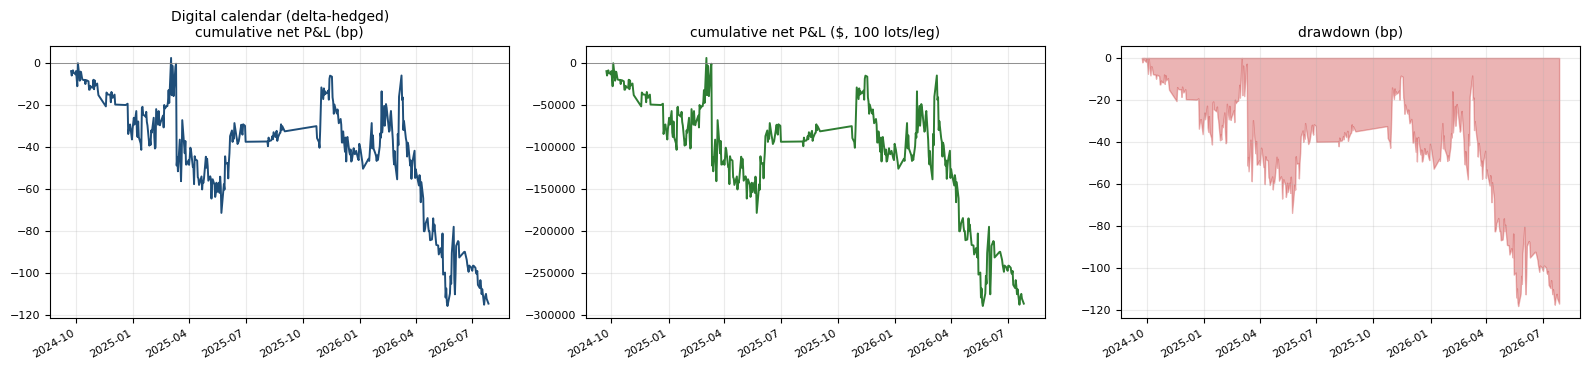

In [14]:
cfg_hdg = config_from_row(BASE_HEDGED, best_hdg, PARAMS)
res_hdg = run_backtest(cfg_hdg, signals=sig_atm, book=lab["book"],
                       builder=builder_atm)
_ = header_block("Digital calendar, DELTA-HEDGED — best config", res_hdg,
                 grid=grid_hdg,
                 note="both contracts' option deltas re-hedged daily on their "
                      "own futures")
if not res_hdg.daily_bp.empty:
    fig = three_panel_equity(res_hdg, "Digital calendar (delta-hedged)")
    plt.show()

In [15]:
cfg_atm = config_from_row(BASE, best_atm, PARAMS)
res_atm = run_backtest(cfg_atm, signals=sig_atm, book=lab["book"],
                       builder=builder_atm)
_ = header_block("Digital calendar, UNHEDGED — diagnostic only", res_atm,
                 grid=grid_atm,
                 note="carries the futures calendar spread; NOT an "
                      "options-vs-futures result")
res_fut = run_backtest(config_from_row(BASE, best_fut, PARAMS), signals=sig_atm,
                       book=lab["book"], builder=builder_futures_only)
_ = header_block("Futures calendar spread — same signal, no options", res_fut,
                 grid=grid_fut)

Digital calendar, UNHEDGED — diagnostic only  |  fade|ma10|w60|z2.5|z0|lag1|every1  |  100 contracts/leg ($2,500/bp)
  carries the futures calendar spread; NOT an options-vs-futures result
  1 package = 48 contracts -> position = 4,800 contracts across all legs
  trades    68   skipped    0   hit 37%   avg -1.118bp   avg hold 16.2d   stale 0.0%
  total     -76.00bp   $    -190,000   gross +94.00bp
  daily-MTM Sharpe -0.41   maxDD -146.00bp ($-365,000)   worst trade -22.50bp
  t(trade) -0.99   NW t(daily) -0.61   non-overlap SR -0.09   DSR p=0.004 over 108 trials
Futures calendar spread — same signal, no options  |  momentum|ma5|w60|z2.5|z0|lag1|every1  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades    82   skipped    0   hit 48%   avg -0.896bp   avg hold 14.3d   stale 0.0%
  total     -73.50bp   $    -183,750   gross +131.50bp
  daily-MTM Sharpe -0.59   maxDD -134.50bp ($-336,250)   worst trade -17.50bp
  t(trade) -1.18  

In [16]:
print("EXIT COMPARISON (hedged)")
print(exit_comparison(cfg_hdg, signals=sig_atm, book=lab["book"],
                      builder=builder_atm).to_string(index=False))
print("\nMARKS x LAG (hedged)")
print(marks_x_lag_panel(cfg_hdg, signals=sig_atm, book=lab["book"],
                        builder=builder_atm).to_string(index=False))
_ = cost_block(res_hdg)

EXIT COMPARISON (hedged)


exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        70     0.400      -1.640      -114.812     -287030.75  -0.684   -118.227         17.529
half        70     0.371      -1.750      -122.467     -306168.25  -0.755   -122.196         16.700
  t5       120     0.350      -1.716      -205.874     -514684.25  -1.975   -213.216          4.933
 t10        87     0.287      -2.593      -225.594     -563985.00  -1.564   -225.323          9.954
 t20        69     0.391      -2.245      -154.932     -387330.75  -0.880   -154.661         19.391

MARKS x LAG (hedged)


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        71         133.002       -44.498  -0.256     0.479
       listed    1        70          60.188      -114.812  -0.684     0.400

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 70        60.188        0.86     0.543      150469.25
           0.5 70        25.188        0.36     0.500       62969.25
           1.0 70        -9.812       -0.14     0.471      -24530.75
           1.5 70       -44.812       -0.64     0.471     -112030.75
           2.5 70      -114.812       -1.64     0.400     -287030.75
           4.0 70      -219.812       -3.14     0.214     -549530.75


In [17]:
if not res_hdg.trades.empty:
    print(res_hdg.trades.sort_values("entry").head(40).to_string(index=False))

          key  dir            structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts    exit_reason
SFRZ25-SFRH26   -1 digcal SFRZ25-SFRH26  2024-09-19 2024-09-20 2024-10-21    20  2.513    3.0353      2.5   0.5353   1338.23         0.0           32.0       max_hold
SFRU25-SFRH26   -1 digcal SFRU25-SFRH26  2024-09-19 2024-09-20 2024-10-25    17  2.580   -9.2489      2.5 -11.7489 -29372.36         0.0           48.0 mean_reversion
SFRM25-SFRU25    1 digcal SFRM25-SFRU25  2024-10-18 2024-10-21 2024-11-06    10 -2.603   -1.7248      2.5  -4.2248 -10562.08         0.0           64.0 mean_reversion
SFRH25-SFRU25   -1 digcal SFRH25-SFRU25  2024-11-14 2024-11-15 2024-12-03    10  2.733   -2.0028      2.5  -4.5028 -11256.95         0.0           64.0 mean_reversion
SFRH25-SFRU25   -1 digcal SFRH25-SFRU25  2024-12-18 2024-12-19 2025-01-21    20  2.731   -8.6346      2.5 -11.1346 -27836.53         0.0           64.0       max_hol

## Step 5 — the shape (strike-butterfly of calendars)

This is the part of the profile that the futures market cannot pin at all.
Twelve option legs, so the per-leg cost model matters more than the flat one.

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs


  108 configs | median -435.50bp | IQR [-812.25, -65.88] | 16% net-positive | best +326.00bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade   5            120               2.0        t10       168     0.542       1.940         326.0       815000.0   0.624     -239.5
     fade   5            120               2.0       half       152     0.539       1.743         265.0       662500.0   0.509     -279.0
     fade   1            120               2.5        t10       119     0.496       1.929         229.5       573750.0   0.566     -250.5
     fade   5            120               1.5        t10       239     0.506       0.851         203.5       508750.0   0.333     -262.0
     fade  10            120               2.5         z0        82     0.598       2.146         176.0       440000.0   0.365     -213.0
     fade

Digital-calendar shape (strike fly) — best config  |  fade|ma5|w120|z2.0|t10|lag1|every1  |  100 contracts/leg ($2,500/bp)
  12 option legs; per-leg round trip = 12bp
  1 package = 224 contracts -> position = 22,400 contracts across all legs
  trades   168   skipped    0   hit 54%   avg +1.940bp   avg hold 9.8d   stale 0.0%
  total    +326.00bp   $    +815,000   gross +746.00bp
  daily-MTM Sharpe +0.62   maxDD -239.50bp ($-598,750)   worst trade -30.50bp
  t(trade) +1.72   NW t(daily) +1.18   non-overlap SR -0.22   DSR p=0.015 over 108 trials


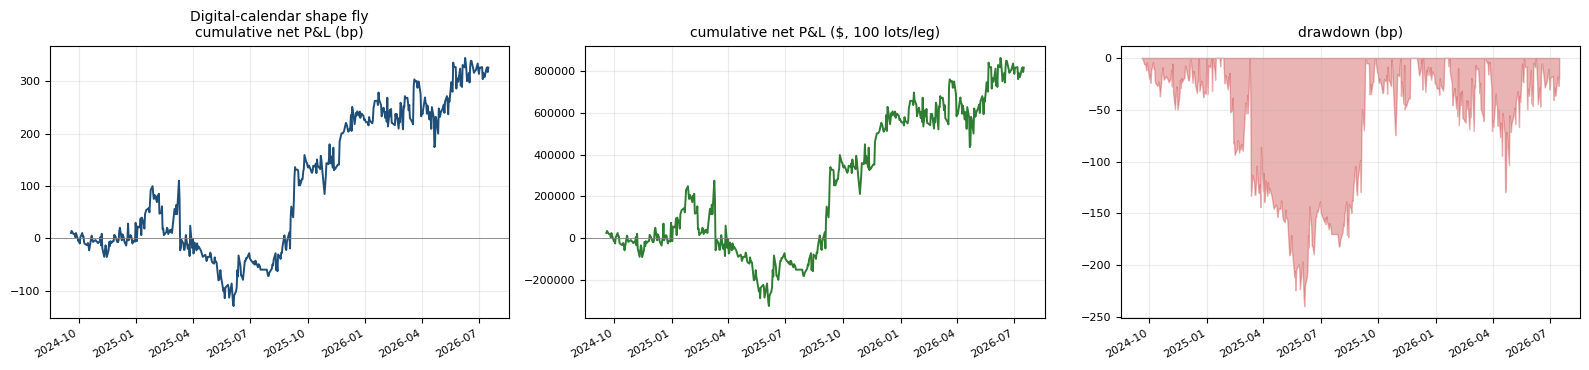


  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 168         746.0        4.44     0.589      1865000.0
           0.5 168         662.0        3.94     0.589      1655000.0
           1.0 168         578.0        3.44     0.589      1445000.0
           1.5 168         494.0        2.94     0.589      1235000.0
           2.5 168         326.0        1.94     0.542       815000.0
           4.0 168          74.0        0.44     0.417       185000.0


In [18]:
grid_fly = grid_search(GRID, signals=sig_fly, book=lab["book"],
                       builder=builder_fly, base=BASE, show_progress=True)
best_fly = grid_block(grid_fly, PARAMS)
cfg_fly = config_from_row(BASE, best_fly, PARAMS)
res_fly = run_backtest(cfg_fly, signals=sig_fly, book=lab["book"],
                       builder=builder_fly)
_ = header_block("Digital-calendar shape (strike fly) — best config", res_fly,
                 grid=grid_fly, note="12 option legs; per-leg round trip = 12bp")
if not res_fly.daily_bp.empty:
    fig = three_panel_equity(res_fly, "Digital-calendar shape fly")
    plt.show()
_ = cost_block(res_fly)

## League rows

In [19]:
med_hdg = median_row(grid_hdg)
res_med = run_backtest(config_from_row(BASE_HEDGED, med_hdg, PARAMS),
                       signals=sig_atm, book=lab["book"], builder=builder_atm)
_ = header_block("Digital calendar hedged — median config", res_med, grid=grid_hdg)

Digital calendar hedged — median config  |  fade|ma5|w60|z1.5|z0|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 48 contracts -> position = 4,800 contracts across all legs
  trades   190   skipped    0   hit 31%   avg -2.881bp   avg hold 14.6d   stale 0.0%
  total    -547.32bp   $  -1,368,293   gross -72.32bp
  daily-MTM Sharpe -2.00   maxDD -559.62bp ($-1,399,039)   worst trade -17.21bp
  t(trade) -6.64   NW t(daily) -3.80   non-overlap SR -0.31   DSR p=0.000 over 108 trials


In [20]:
league_row("2. Digital calendar (delta-hedged)", "best-config", res_hdg,
           grid=grid_hdg, cls="B", note="4 option legs + daily futures hedge")
league_row("2. Digital calendar (delta-hedged)", "median-config", res_med,
           grid=grid_hdg, cls="B", note="median of the sweep, not selected")
league_row("2. Digital calendar (UNHEDGED)", "diagnostic", res_atm,
           grid=grid_atm, cls="B",
           note="DIAGNOSTIC: carries the futures calendar spread, not RV")
league_row("2b. Futures calendar spread", "same-signal-benchmark", res_fut,
           grid=grid_fut, cls="linear",
           note="the benchmark the options must beat to mean anything")
league_row("2c. Digital-calendar shape fly", "best-config", res_fly,
           grid=grid_fly, cls="B", note="12 option legs — cost-dominated")


  LEAGUE ROW  2. Digital calendar (delta-hedged) / best-config: MARGINAL-maker-only  (taker -114.81bp, maker +60.19bp, DSR p=0.000)

  LEAGUE ROW  2. Digital calendar (delta-hedged) / median-config: DEAD  (taker -547.32bp, maker -72.32bp, DSR p=0.000)

  LEAGUE ROW  2. Digital calendar (UNHEDGED) / diagnostic: MARGINAL-maker-only  (taker -76.00bp, maker +94.00bp, DSR p=0.004)

  LEAGUE ROW  2b. Futures calendar spread / same-signal-benchmark: MARGINAL-maker-only  (taker -73.50bp, maker +131.50bp, DSR p=0.000)

  LEAGUE ROW  2c. Digital-calendar shape fly / best-config: SELECTION-ARTIFACT  (taker +326.00bp, maker +746.00bp, DSR p=0.015)


{'framework': '2c. Digital-calendar shape fly',
 'variant': 'best-config',
 'class': 'B',
 'config': 'fade|ma5|w120|z2.0|t10|lag1|every1',
 'n_trades': 168,
 'hit_rate': 0.5416666666666666,
 'avg_net_bp': 1.9404761904761905,
 'total_gross_bp': 746.0,
 'total_net_bp': 326.0,
 'total_net_usd': 815000.0,
 'net_bp_maker': 746.0,
 'net_bp_taker': 326.0,
 'net_usd_taker': 815000.0,
 'sharpe': 0.6239387851016662,
 'max_dd_bp': -239.49999999998786,
 'max_dd_usd': -598749.9999999696,
 'avg_hold_days': 9.845238095238095,
 'dsr_prob': 0.015397200851625353,
 'grid_median_net_bp': -435.5,
 'nonoverlap_sharpe': -0.2176411298859986,
 'verdict': 'SELECTION-ARTIFACT',
 'note': '12 option legs — cost-dominated'}